In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import re

In [2]:
def Read_all_csv(folder_path):
    dataframe={}
    for file in glob.glob(os.path.join(folder_path,"*.csv")):
        name = file.split("\\")[-1].replace(".csv","")
        dataframe[name]=pd.read_csv(file)
    return dataframe

In [3]:
folder_path = "D:\\DATA SETS (Project)\\Capston Project Data\\Superstore_Marketing_Campaign_Analysis"
dfs = Read_all_csv(folder_path)
data = dfs['Superstore Marketing Campaign Dataset']
data.head()
data.columns = data.columns.str.strip()

In [4]:
print(data.shape)
print(data.info())
print(data.describe())

(2240, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 n

In [5]:
data.columns

Index(['Id', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Response', 'Complain'],
      dtype='object')

In [6]:
data = data.copy()

In [7]:
data.isnull().sum()

Id                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Response                0
Complain                0
dtype: int64

In [8]:
data['Id'].nunique()

2240

In [9]:
print(data['Year_Birth'].min())
print(data['Year_Birth'].max())
print(data['Year_Birth'].unique())

1893
1996
[1970 1961 1958 1967 1989 1954 1947 1979 1959 1981 1969 1977 1960 1966
 1976 1965 1956 1975 1971 1986 1972 1974 1990 1987 1984 1968 1955 1983
 1973 1978 1952 1962 1964 1982 1963 1957 1980 1945 1949 1948 1953 1946
 1985 1992 1944 1951 1988 1950 1994 1993 1991 1893 1996 1995 1899 1943
 1941 1940 1900]


In [10]:
import datetime
data['Age'] = datetime.datetime.now().year - data['Year_Birth']
data[data['Age'] > 90]
data = data[data['Age'] <= 90]

In [11]:
data['Education'].value_counts()

Education
Graduation    1127
PhD            485
Master         370
2n Cycle       201
Basic           54
Name: count, dtype: int64

In [12]:
data['Education'] = data['Education'].replace({
    'Graduation' : 'Graduate',
    'PhD'        : 'Postgraduate',
    'Master'     : 'Postgraduate',
    '2n Cycle'   : 'Undergraduate',
    'Basic'      : 'Undergraduate'
})

In [13]:
data['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    579
Single      479
Divorced    231
Widow        77
Alone         3
YOLO          2
Absurd        2
Name: count, dtype: int64

In [14]:
data['Marital_Status'] = data['Marital_Status'].replace({
    'Together' : 'Married',
    'Alone'    : 'Single',
    'YOLO'     : 'Single',
    'Absurd'   : 'Single'
})

In [15]:
data['Income'].isnull().sum()
data['Income'].fillna(data['Income'].median() , inplace = True)

C:\Users\user\AppData\Local\Temp\ipykernel_8752\2410249422.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Income'].fillna(data['Income'].median() , inplace = True)


In [16]:
print(data['Income'].max())
print(data['Income'].min())

666666.0
1730.0


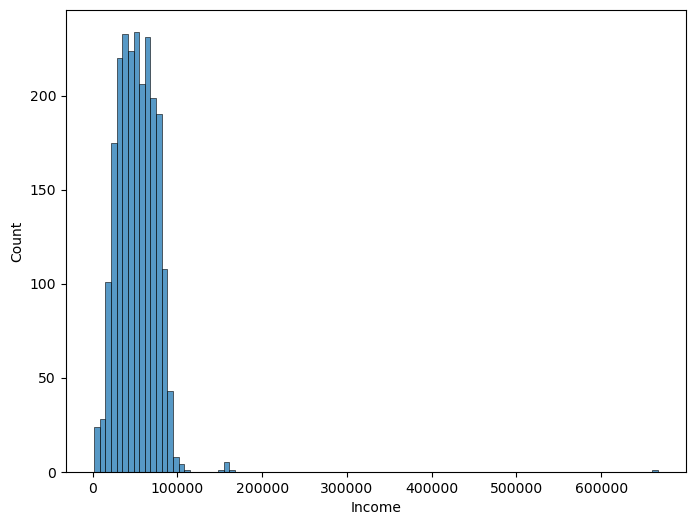

In [17]:
plt.figure(figsize =(8,6))
sns.histplot(data['Income'] , bins = 100 )
plt.show()

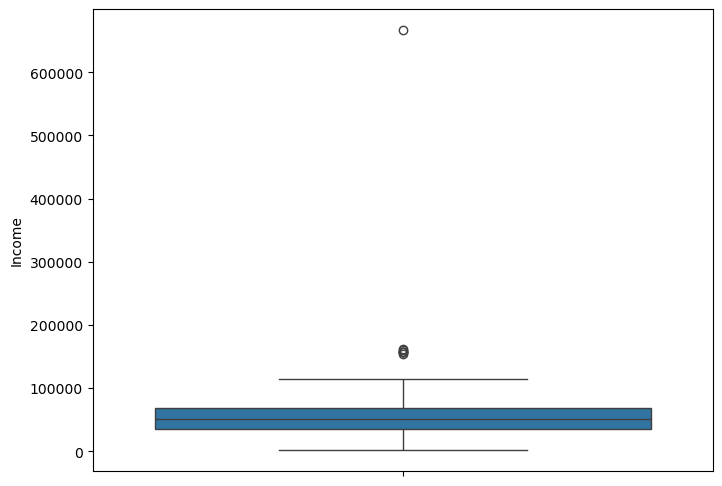

In [18]:
plt.figure(figsize =(8,6))
sns.boxplot(data['Income'] )
plt.show()

In [19]:
data[data['Income'] > 200000]

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
527,9432,1977,Graduate,Married,666666.0,1,0,2/6/13,23,9,...,1,12,4,3,1,3,6,0,0,49


In [20]:
# IQR
Q1 = data['Income'].quantile(0.25)
Q3 = data['Income'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
data[data['Income'] >= upper]

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
325,4931,1977,Graduate,Married,157146.0,0,0,4/29/13,13,1,...,1,1,0,0,28,0,1,0,0,49
497,1501,1982,Postgraduate,Married,160803.0,0,0,4/8/12,21,55,...,3,4,15,0,28,1,0,0,0,44
527,9432,1977,Graduate,Married,666666.0,1,0,2/6/13,23,9,...,1,12,4,3,1,3,6,0,0,49
731,1503,1976,Postgraduate,Married,162397.0,1,1,3/6/13,31,85,...,1,2,0,0,0,1,1,0,0,50
853,5336,1971,Postgraduate,Married,157733.0,1,0,4/6/13,37,39,...,0,8,0,1,0,1,1,0,0,55
1826,5555,1975,Graduate,Divorced,153924.0,0,0,7/2/14,81,1,...,1,1,0,0,0,0,0,0,0,51
1925,11181,1949,Postgraduate,Married,156924.0,0,0,8/29/13,85,2,...,1,1,0,0,0,0,0,0,0,77
2204,8475,1973,Postgraduate,Married,157243.0,0,1,1/3/14,98,20,...,2,1,15,0,22,0,0,0,0,53


In [21]:
data = data[data['Income'] <= Q3 + 1.5 * IQR]

In [22]:
data.shape

(2229, 23)

In [23]:
data['Kidhome'].value_counts()             

Kidhome
0    1286
1     895
2      48
Name: count, dtype: int64

In [24]:
data['Teenhome'].unique()               

array([0, 1, 2])

In [25]:
data.columns

Index(['Id', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Response', 'Complain', 'Age'],
      dtype='object')

In [26]:
data['Dt_Customer'].dtype

dtype('O')

In [27]:
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'])

C:\Users\user\AppData\Local\Temp\ipykernel_8752\825795003.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'])


In [28]:
print(data['Recency'].dtype)
print(data['Recency'].unique())

int64
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]


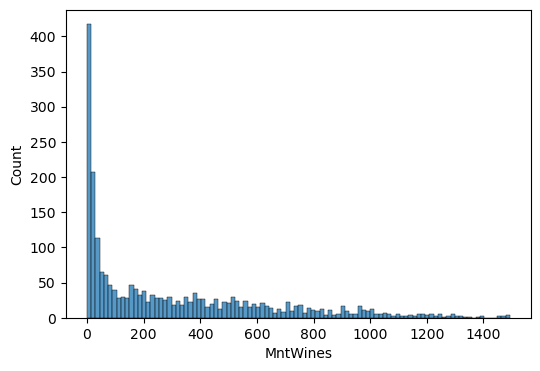

In [29]:
plt.figure(figsize =(6,4))
sns.histplot(data['MntWines'] , bins = 100)
plt.show()

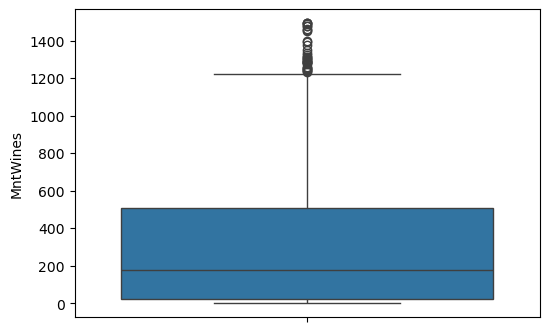

In [30]:
plt.figure(figsize =(6,4))
sns.boxplot(data['MntWines'])
plt.show()

<Axes: ylabel='MntFruits'>

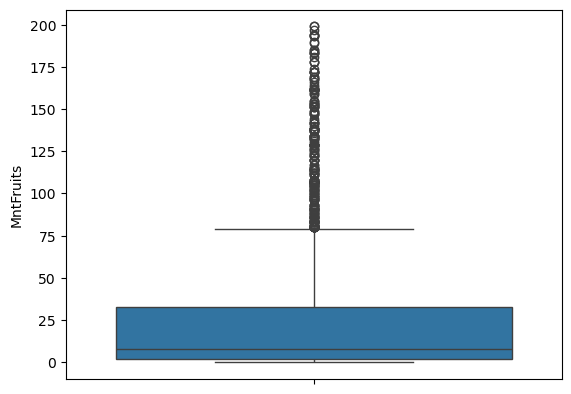

In [31]:
sns.boxplot(data['MntFruits'])

<Axes: xlabel='MntFruits', ylabel='Count'>

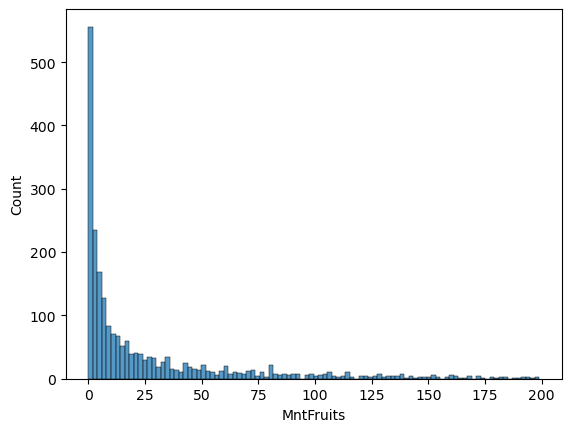

In [32]:
sns.histplot(data['MntFruits'] , bins = 100)

In [33]:
data['MntFruits'].dtype

dtype('int64')

In [34]:
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

data[spend_cols].describe()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
count,2229.000000,2229.000000,2229.000000,2229.000000,2229.000000,2229.000000
mean,304.991476,26.348587,165.283984,37.642441,27.161507,44.113055
std,336.761943,39.764060,219.336589,54.700548,41.338945,52.091255
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000
50%,176.000000,8.000000,67.000000,12.000000,8.000000,24.000000
75%,505.000000,33.000000,231.000000,50.000000,34.000000,56.000000
max,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000


In [37]:
data['NumDealsPurchases'].dtype

dtype('int64')

In [60]:
data['NumDealsPurchases'].value_counts()

NumDealsPurchases
1     967
2     497
3     297
4     188
5      94
6      61
7      40
0      37
8      14
9       8
11      5
10      5
12      4
15      4
13      3
Name: count, dtype: int64

In [40]:
data.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
0,1826,1970,Graduate,Divorced,84835.0,0,0,2014-06-16,0,189,...,189,218,1,4,4,6,1,1,0,56
1,1,1961,Graduate,Single,57091.0,0,0,2014-06-15,0,464,...,0,37,1,7,3,7,5,1,0,65
2,10476,1958,Graduate,Married,67267.0,0,1,2014-05-13,0,134,...,2,30,1,3,2,5,2,0,0,68
3,1386,1967,Graduate,Married,32474.0,1,1,2014-11-05,0,10,...,0,0,1,1,0,2,7,0,0,59
4,5371,1989,Graduate,Single,21474.0,1,0,2014-08-04,0,6,...,0,34,2,3,1,2,7,1,0,37


In [43]:
print(data['NumWebPurchases'].dtype)
print(data['NumWebPurchases'].nunique())
print(data['NumWebPurchases'].value_counts())

int64
15
NumWebPurchases
2     372
1     352
3     335
4     279
5     220
6     205
7     155
8     102
9      75
11     44
10     43
0      43
27      2
25      1
23      1
Name: count, dtype: int64


In [52]:
data[data['NumWebPurchases'] >= 23]

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
14,10311,1969,Graduate,Married,4428.0,0,1,2013-05-10,0,16,...,4,321,0,25,0,0,1,0,0,57
210,4619,1945,Postgraduate,Single,113734.0,0,0,2014-05-28,9,6,...,262,3,0,27,0,0,1,0,0,81
449,5255,1986,Graduate,Single,51373.0,1,0,2013-02-20,19,5,...,263,362,0,27,0,0,1,0,0,40
2063,6237,1966,Postgraduate,Single,7144.0,0,2,2013-07-12,92,81,...,2,291,0,23,1,1,0,0,0,60


In [55]:
data = data[data['NumWebPurchases'] < 23]

In [56]:
print(data['NumCatalogPurchases'].dtype)
print(data['NumCatalogPurchases'].nunique())
print(data['NumCatalogPurchases'].value_counts())

int64
12
NumCatalogPurchases
0     578
1     494
2     276
3     184
4     182
5     140
6     127
7      79
8      55
10     48
9      42
11     19
Name: count, dtype: int64


In [57]:
data[data['NumCatalogPurchases']== 28]

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age


In [58]:
data = data[data['NumCatalogPurchases'] != 28]

In [59]:
data['NumStorePurchases'].value_counts()

NumStorePurchases
3     489
4     322
2     221
5     212
6     178
8     149
7     143
10    125
9     106
12    105
13     83
11     81
0       7
1       3
Name: count, dtype: int64

In [61]:
data['NumWebVisitsMonth'].value_counts()

NumWebVisitsMonth
7     393
8     342
6     339
5     280
4     217
3     205
2     202
1     145
9      83
0       6
20      3
10      3
14      2
19      2
13      1
17      1
Name: count, dtype: int64

In [65]:
data[data['NumWebVisitsMonth'] >= 13]

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
60,4246,1982,Postgraduate,Single,6560.0,0,0,2013-12-12,2,67,...,3,262,0,1,0,1,17,0,0,44
299,9303,1976,Graduate,Married,5305.0,0,1,2013-07-30,12,12,...,3,5,0,1,0,0,13,0,0,50
456,3955,1965,Graduate,Divorced,4861.0,0,0,2014-06-22,20,2,...,0,1,0,0,0,0,14,0,0,61
663,9931,1963,Postgraduate,Married,4023.0,1,1,2014-06-23,29,5,...,1,1,15,0,0,0,19,0,0,63
1291,11110,1973,Graduate,Single,3502.0,1,0,2013-04-13,56,2,...,0,1,0,0,0,0,14,0,0,53
1416,10749,1991,Graduate,Single,8028.0,0,0,2012-09-18,62,73,...,12,2,15,0,1,0,19,0,0,35
1466,6862,1971,Graduate,Divorced,1730.0,0,0,2014-05-18,65,1,...,1,1,15,0,0,0,20,0,0,55
1533,5899,1950,Postgraduate,Married,5648.0,1,1,2014-03-13,68,28,...,1,13,1,1,0,0,20,0,0,76
1721,4303,1957,Postgraduate,Married,6835.0,0,1,2012-08-12,76,107,...,2,12,0,0,0,1,20,0,0,69


In [66]:
data = data[data['NumWebVisitsMonth'] <13]

In [67]:
data['Response'].value_counts()

Response
0    1881
1     334
Name: count, dtype: int64

In [68]:
data['Complain'].value_counts()

Complain
0    2195
1      20
Name: count, dtype: int64

In [69]:
data['Age'].value_counts()

Age
50    87
55    85
51    82
54    79
56    77
48    77
61    73
53    72
57    70
52    69
70    55
68    53
47    52
74    52
58    51
67    51
72    50
49    50
66    49
71    49
60    49
59    44
64    44
63    44
75    43
44    43
62    42
69    42
43    42
40    41
46    39
45    39
42    38
65    36
73    35
41    32
37    30
77    29
38    29
76    28
39    27
78    21
36    18
79    16
80    16
35    14
34    13
81     7
82     7
83     7
31     5
33     5
32     3
30     2
85     1
86     1
Name: count, dtype: int64

In [70]:
data[data['Age'] >=85]

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
1740,6932,1941,Postgraduate,Married,93027.0,0,0,2013-04-13,77,1285,...,0,21,0,7,10,5,2,0,0,85
2171,6663,1940,Postgraduate,Single,51141.0,0,0,2013-08-07,96,144,...,0,6,1,3,1,4,5,0,0,86
